In [1]:
# import required libraries and setup path
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# append root directory to path
sys.path.append(os.path.abspath('../'))
from src.volatility import calculate_historical_volatility, estimate_parkinson_volatility

In [2]:
# load the cleaned market data
input_path = '../data/processed/spy_cleaned_1m.csv'
df = pd.read_csv(input_path)

# convert datetime column to actual datetime objects and set as index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

# verify the data loaded correctly
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Datetime,,,,,,,,
2026-02-25 09:30:00-05:00,690.969971,690.973999,690.940002,690.973999,1898474,0.0,0.0,0.0
2026-02-25 09:31:00-05:00,690.960022,691.239990,690.609985,690.729980,288626,0.0,0.0,0.0
2026-02-25 09:32:00-05:00,690.750000,690.950012,690.619995,690.655029,192914,0.0,0.0,0.0
2026-02-25 09:33:00-05:00,690.640015,690.890015,690.609985,690.820007,183967,0.0,0.0,0.0
2026-02-25 09:34:00-05:00,690.840027,691.010010,690.780029,690.840027,212029,0.0,0.0,0.0


In [3]:
# calculate a rolling 60-minute volatility
window_size = 60
df['historical_vol'] = calculate_historical_volatility(df['Close'], window=window_size)
df['parkinson_vol'] = estimate_parkinson_volatility(df['High'], df['Low'], window=window_size)

# drop the initial nan values created by the rolling window
df_vol = df.dropna(subset=['historical_vol', 'parkinson_vol'])

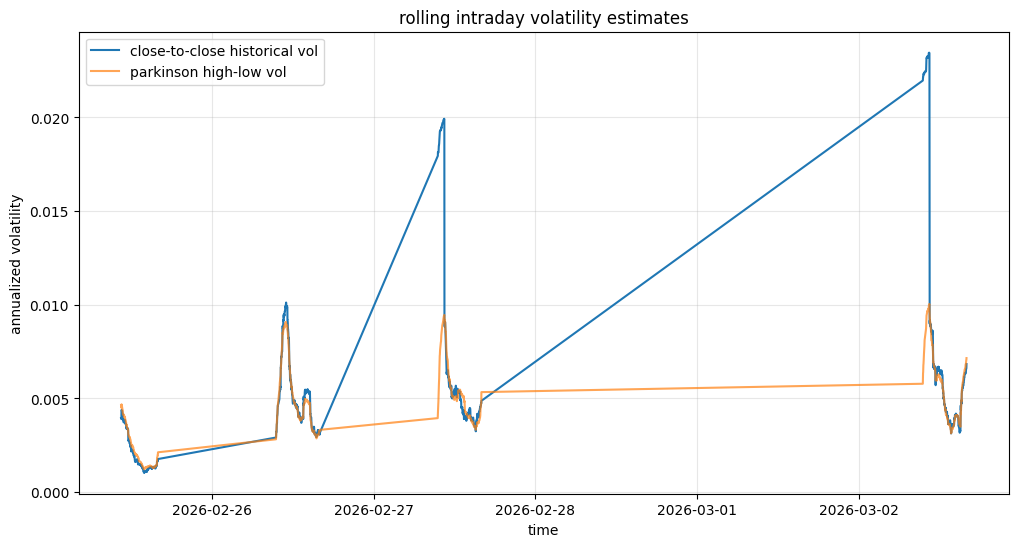

In [4]:
# plot the volatility estimates to compare them
plt.figure(figsize=(12, 6))
plt.plot(df_vol.index, df_vol['historical_vol'], label='close-to-close historical vol')
plt.plot(df_vol.index, df_vol['parkinson_vol'], label='parkinson high-low vol', alpha=0.7)

plt.title('rolling intraday volatility estimates')
plt.ylabel('annualized volatility')
plt.xlabel('time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()